In [ ]:
!pip install h5py imageio

In [109]:
from h5py import File

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import imageio

import os

from scipy.interpolate import interp1d
from scipy.optimize import bisect

from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigs

from tqdm import tqdm, trange

In [3]:
FILE_PATH = "/Users/2929332h/Library/CloudStorage/OneDrive-UniversityofGlasgow/PhD/Code/SchumpeterCournot/output/3-firm/policy_by_relative_state_70.jld2"

In [4]:
model_settings = {
    "SavedAt": "2026-04-01T17:51:41.497",
    "ModelEnvironment": {
        "tau_max": 70,
        "l_max": 0.3
    },
    "SolverState": {
        "is_converged": True,
    },
    "ModelParameters": {
        "sigma": 1.2,
        "n": 3,
        "alpha": 5,
        "gamma": 1.03,
        "PROB": "SQRT",
        "beta": 0.95
    },
    "ModelSettings": {
        "tol_update": 1.0e-6,
        "INNOV_TYPE": "NonChanging",
        "solver_value_scaling": "Levels()",
        "clamp_rate_update": 0.1,
        "sdf_relaxer": 1,
        "max_iter_update": 500
    },
    "Timestamp": "2026-04-01T17:51:41.479"
}

In [5]:
with File(FILE_PATH, "r") as f:
    p_grid = f["p_grid"][:]
    d_states = f["d_states"][:]

p_grid = np.array(p_grid)[1:-1, 1:-1]  # Remove first and last rows and columns
d_states = np.array(d_states)[1:-1]  # Remove first and last elements

# p_grid = p_grid[::-1, ::-1]  # Flip vertically to match Cartesian coordinates

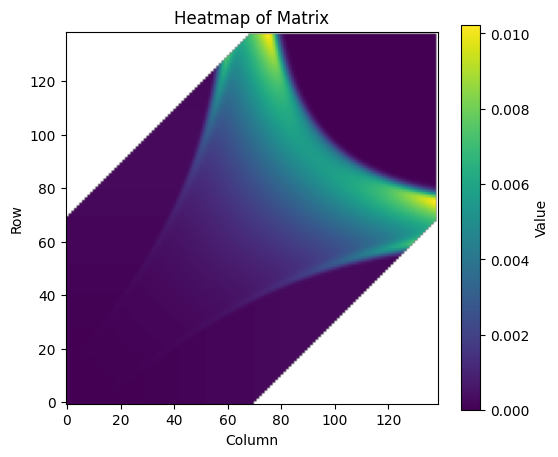

In [6]:
plt.figure(figsize=(6,5))
plt.imshow(p_grid, cmap='viridis', origin='lower')  # origin='lower' matches typical Cartesian
plt.colorbar(label='Value')
plt.title('Heatmap of Matrix')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

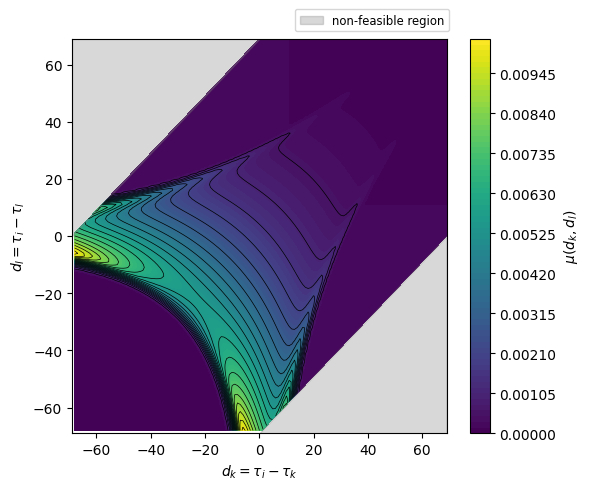

In [7]:
plt.figure(figsize=(6,5))
X, Y = np.meshgrid(d_states * -1, d_states * -1)  # must use meshgrid for contour
plt.contourf(X, Y, p_grid, levels=100)
plt.colorbar(label=r'$\mu(d_k, d_l)$')
plt.contour(X, Y, p_grid, levels=20, colors='black', linewidths=0.5)
plt.xlabel(r'$d_k = \tau_i - \tau_k$')
plt.ylabel(r'$d_l = \tau_i - \tau_l$')
v_min, v_max = plt.gca().get_ylim()

plt.fill_between(d_states, [v_min for _ in d_states], d_states + v_min, 
                color='gray', alpha=0.3, label='non-feasible region')
plt.fill_between(d_states, d_states + v_max, [v_max for _ in d_states], 
                color='gray', alpha=0.3)


plt.xlim(v_min, v_max)
plt.ylim(v_min, v_max)

plt.legend(loc='upper left', bbox_to_anchor=(0.58, 1.09), fontsize='small')
plt.tight_layout()
plt.show()

In [8]:
GAMMA = 1.03
SIGMA = 1.2

def is_firm_active(tau_list):
    global GAMMA, SIGMA
    n = len(tau_list)
    a_list = np.array([GAMMA ** tau for tau in tau_list])
    a_tilde = np.mean(1 / a_list) ** (-1)
    threshold = a_tilde * (n - SIGMA) / (n)
    return np.array([a > threshold for a in a_list])

In [9]:
def find_activation_boundary(tau_list, idx_change, min_d, max_d, tol=1e-5, max_iter=1000, itr=0):
    tau_list_tmp = tau_list.copy()
    
    if itr == 0:
        tau_list_tmp[idx_change] = max_d
        active_top = is_firm_active(tau_list_tmp)

        tau_list_tmp[idx_change] = min_d
        active_bottom = is_firm_active(tau_list_tmp)

        if active_top[idx_change] == active_bottom[idx_change]:
            return np.nan
        if active_top[idx_change]:
            return find_activation_boundary(tau_list, idx_change, min_d, max_d, tol, max_iter, itr=1)
        if active_bottom[idx_change]:
            return find_activation_boundary(tau_list, idx_change, max_d, min_d, tol, max_iter, itr=1)
    
    if itr > max_iter:
        print("Max iterations reached without convergence.")
        return (min_d + max_d) / 2
    
    if np.abs(max_d - min_d) < tol:
        return (min_d + max_d) / 2
    
    mid_d = (min_d + max_d) / 2
    tau_list_tmp[idx_change] = mid_d
    active_mid = is_firm_active(tau_list_tmp)
    
    if active_mid[idx_change]:
        return find_activation_boundary(tau_list, idx_change, min_d, mid_d, tol, max_iter, itr=itr+1)
    else:
        return find_activation_boundary(tau_list, idx_change, mid_d, max_d, tol, max_iter, itr=itr+1)


In [10]:
bnd_3 = np.array([
    find_activation_boundary([0, i, 0], 2, -70, 70) 
    for i in d_states
])

bnd_2 = np.array([
    find_activation_boundary([0, 0, i], 1, -70, 70) 
    for i in d_states
])

bnd_1 = np.array([
    find_activation_boundary([0, i, 0], 0, -70, 70) 
    for i in d_states
])
bnd_1 = np.array([[i, i-j] for i, j in zip(bnd_1, d_states) if not np.isnan(i)])

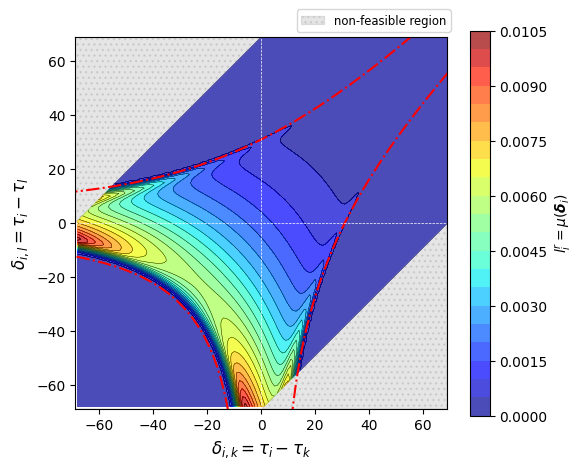

In [136]:
plt.figure(figsize=(6,5))
plt.gca().set_aspect('equal', adjustable='box')
X, Y = np.meshgrid(d_states * -1, d_states * -1)  # must use meshgrid for contour
plt.contourf(X, Y, p_grid, levels=20, alpha=0.7, cmap='jet')
# add colorbar with scientific notation
plt.colorbar(label=r'$l^r_i = \mu(\boldsymbol{\delta}_i)$')
plt.contour(X, Y, p_grid, levels=20, colors='black', linewidths=0.3)
plt.xlabel(r'$\delta_{i,k} = \tau_i - \tau_k$', fontsize=12)
plt.ylabel(r'$\delta_{i,l} = \tau_i - \tau_l$', fontsize=12)
v_min, v_max = plt.gca().get_ylim()

plt.fill_between(d_states, [v_min for _ in d_states], d_states + v_min, 
                color='gray', alpha=0.2, hatch="...", label='non-feasible region')
plt.fill_between(d_states, d_states + v_max, [v_max for _ in d_states], 
                color='gray', alpha=0.2, hatch="...")

plt.legend(loc='upper left', bbox_to_anchor=(0.58, 1.09), fontsize='small')

plt.plot(bnd_3 * -1, d_states * -1, 'r-.', linewidth=1.5)
plt.plot(d_states * -1, bnd_2 * -1, 'r-.', linewidth=1.5)
plt.plot(bnd_1[:, 0] + 1, bnd_1[:, 1] + 1, 'r-.', linewidth=1.5)

# plt.plot([0], [0], 'o', color='white')
plt.axhline(0, color='white', linestyle='--', linewidth=0.5)
plt.axvline(0, color='white', linestyle='--', linewidth=0.5)

lim = 69
plt.xlim(-lim, lim)
plt.ylim(-lim, lim)
plt.savefig("../output/3-firm/python_plot/policy_by_relative_state.png", dpi=400)

In [12]:
# Find the intersections of the two lines
def find_intersection(x1, y1, x2, y2):
    x_min = max(min(x1), min(x2))
    x_max = min(max(x1), max(x2))

    f1 = interp1d(x1, y1, kind='linear', fill_value='extrapolate')
    f2 = interp1d(x2, y2, kind='linear', fill_value='extrapolate')
    
    def objective(x):
        return f1(x) - f2(x)
    
    # find the root of the objective function using a numerical method (e.g., bisection)
    try:        
        x_intersection = bisect(objective, x_min, x_max)
    except ValueError:
        print("Warning: No intersection found within the common x-range.")
        return np.nan, np.nan
    
    y_pred1 = f1(x_intersection)
    y_pred2 = f2(x_intersection)
    y_pred = (y_pred1 + y_pred2) / 2  # Average the two predictions for better accuracy

    return x_intersection, y_pred

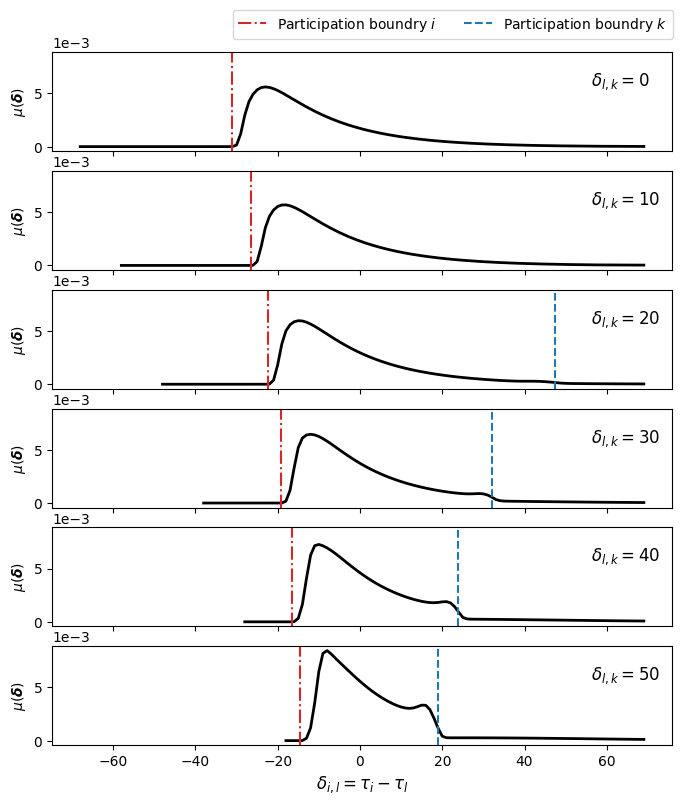

In [13]:
d_other_list = list(range(0, 56, 10))


x1, y1 = bnd_1[:, 0], bnd_1[:, 1]

x3, y3 = d_states * -1, bnd_2 * -1
x3 = x3[[(not f) for f in np.isnan(y3)]]
y3 = y3[[(not f) for f in np.isnan(y3)]]

n_lines = len(d_other_list)
fig, axs = plt.subplots(ncols=1, nrows=n_lines, figsize=(8, 1.5 * n_lines), sharex=True, sharey=True)

for i, d_other in enumerate(d_other_list):
    p_diag = np.array([
        p_grid[i, i + d_other] for i in range(len(d_states) - abs(d_other))
    ])
    axs[i].plot(d_states[:len(p_diag)] * -1, p_diag, color='black', linewidth=2)
    
    axs[i].set_ylabel(r'$\mu(\boldsymbol{\delta})$')
    # axs[i].legend()

    intersection_x, intersection_y = find_intersection(x1, y1, d_states * -1, d_states * -1 + d_other)
    axs[i].axvline(intersection_y, color='tab:red', linestyle='-.', label='Participation boundry $i$')

    intersection_x, intersection_y = find_intersection(x3, y3, d_states * -1, d_states * -1 + d_other)
    axs[i].axvline(intersection_y, color='tab:blue', linestyle='--', label='Participation boundry $k$')

    axs[i].text(0.87, 0.6, f'$\\delta_{{l,k}} = {d_other}$', transform=axs[i].transAxes, fontsize=12, verticalalignment='bottom')


axs[-1].set_xlabel(r'$\delta_{i,l} = \tau_i - \tau_l$', fontsize=12)
axs[0].legend(loc='upper left', bbox_to_anchor=(0.28, 1.5), ncol=2)

# Make all y-axis to show scientific notation
for ax in axs:
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

plt.savefig("../output/3-firm/python_plot/policy_by_relative_state_diagonal_n3.pdf", bbox_inches='tight')

(-69.0, 69.0)

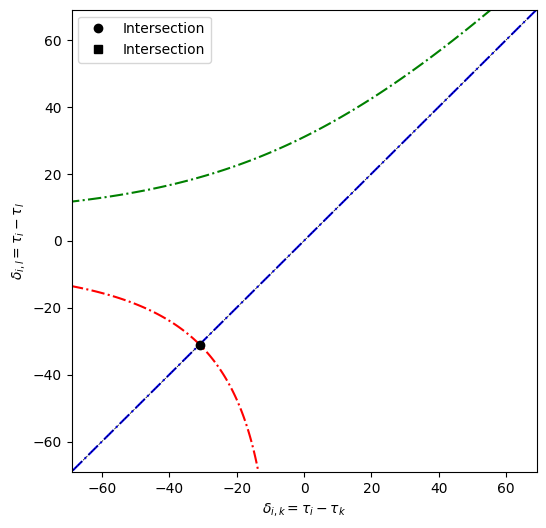

In [14]:
x, y = bnd_1[:, 0], bnd_1[:, 1]
x2, y2 = d_states * -1, d_states * -1 + 0

x3, y3 = d_states * -1, bnd_2 * -1
x3 = x3[[(not f) for f in np.isnan(y3)]]
y3 = y3[[(not f) for f in np.isnan(y3)]]

plt.figure(figsize=(6,6))
plt.plot(x, y, 'r-.', linewidth=1.5)
plt.plot(x2, y2, 'b-.', linewidth=1.5)
plt.plot(x3, y3, 'g-.', linewidth=1.5)
plt.plot(x2, x2, 'k--', linewidth=0.5)

intersection_x, intersection_y = find_intersection(x, y, x2, y2)
plt.plot(intersection_x, intersection_y, 'ko', label='Intersection')

intersection_x, intersection_y = find_intersection(x3, y3, x2, y2)
plt.plot(intersection_x, intersection_y, 'ks', label='Intersection')

plt.xlabel(r'$\delta_{i,k} = \tau_i - \tau_k$')
plt.ylabel(r'$\delta_{i,l} = \tau_i - \tau_l$')
plt.legend()
plt.xlim(-lim, lim)
plt.ylim(-lim, lim)

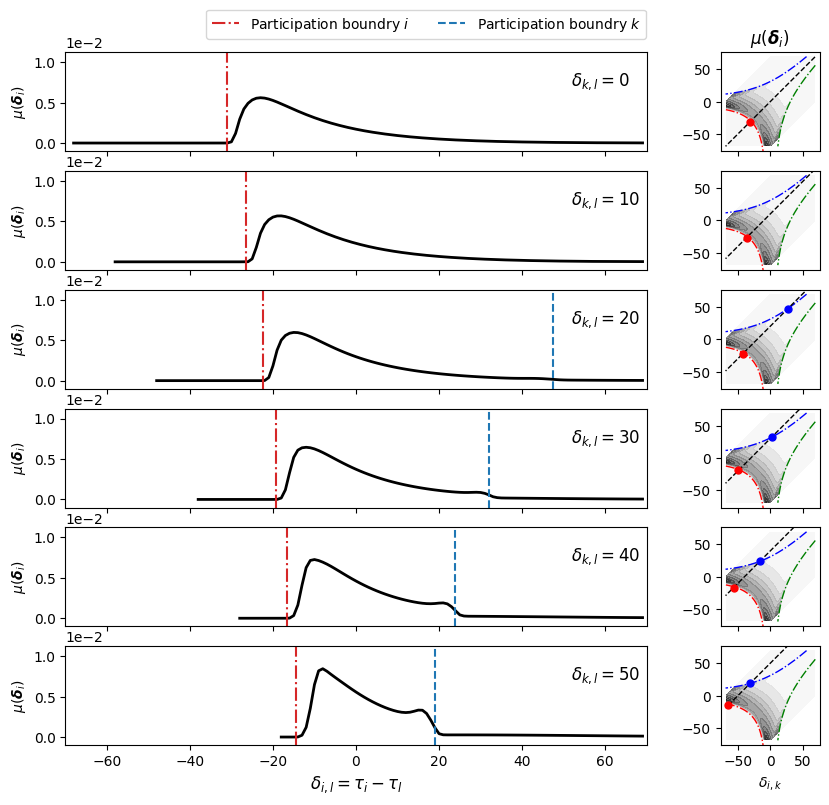

In [137]:
d_other_list = list(range(0, 56, 10))


x1, y1 = bnd_1[:, 0], bnd_1[:, 1]

x3, y3 = d_states * -1, bnd_2 * -1
x3 = x3[[(not f) for f in np.isnan(y3)]]
y3 = y3[[(not f) for f in np.isnan(y3)]]

n_lines = len(d_other_list)
fig, axs2d = plt.subplots(
    ncols=2, nrows=n_lines, 
    figsize=(9.8, 1.5 * n_lines),
    gridspec_kw={'width_ratios': [8, 1.5]},
)

axs = axs2d[:, 0]  # Use the first column for the main plots
for i, d_other in enumerate(d_other_list):
    p_diag = np.array([
        p_grid[i, i + d_other] for i in range(len(d_states) - abs(d_other))
    ])
    axs[i].plot(d_states[:len(p_diag)] * -1, p_diag, color='black', linewidth=2)
    
    axs[i].set_ylabel(r'$\mu(\boldsymbol{\delta}_i)$')

    intersection_x, intersection_y = find_intersection(x1, y1, d_states * -1, d_states * -1 + d_other)
    axs[i].axvline(intersection_y, color='tab:red', linestyle='-.', label='Participation boundry $i$')

    intersection_x, intersection_y = find_intersection(x3, y3, d_states * -1, d_states * -1 + d_other)
    axs[i].axvline(intersection_y, color='tab:blue', linestyle='--', label='Participation boundry $k$')

    axs[i].text(0.87, 0.6, f'$\\delta_{{k,l}} = {d_other}$', transform=axs[i].transAxes, fontsize=12, verticalalignment='bottom')


axs[-1].set_xlabel(r'$\delta_{i,l} = \tau_i - \tau_l$', fontsize=12)
axs[0].legend(loc='upper left', bbox_to_anchor=(0.23, 1.5), ncol=2)


y_max = max(p_grid.flatten())
x_max = p_grid.shape[0] // 2 + 1  # Assuming square grid and that d_states are equally spaced

# Make all y-axis to show scientific notation
for ax in axs:
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    ax.set_ylim(-1e-3, y_max * 1.1)  # Set a common y-axis limit for better comparison
    ax.set_xlim(-x_max, x_max)  # Set a common x-axis limit for better comparison



for ax in axs[:-1]:
    # remove x-axis labels for all but the last subplot
    ax.set_xlabel('')
    ax.set_xticklabels([])


axs2 = axs2d[:, 1]  # Use the second column for the secondary plots
for i, d_other in enumerate(d_other_list):
    # set aspect ratio to 1:1 for the secondary plots
    axs2[i].set_aspect('equal', adjustable='box')

    # plot the policy cuntours in the secondary column
    axs2[i].contourf(X, Y, p_grid, levels=10, alpha=0.7, cmap='gray_r')

    # plot the boundary lines in the secondary column
    axs2[i].plot(bnd_3 * -1, d_states * -1, 'g-.', linewidth=1)
    axs2[i].plot(d_states * -1, bnd_2 * -1, 'b-.', linewidth=1)
    axs2[i].plot(bnd_1[:, 0] + 1, bnd_1[:, 1] + 1, 'r-.', linewidth=1)

    x_min, x_max = axs2[i].get_xlim()

    x_diag, y_diag = d_states * -1, d_states * -1 + d_other
    axs2[i].plot(x_diag, y_diag, 'k--', linewidth=1)

    # plot intersection points
    intersection_x, intersection_y = find_intersection(x1, y1, x_diag, y_diag)
    axs2[i].plot(intersection_x, intersection_y, 'ro', markersize=5)

    intersection_x, intersection_y = find_intersection(x3, y3,  x_diag, y_diag)
    axs2[i].plot(intersection_x, intersection_y, 'bo', markersize=5)


    

    axs2[i].set_xlim(-x_max, x_max)
    axs2[i].set_ylim(-x_max, x_max)

for ax in axs2[:-1]:
    ax.set_xticklabels([])
    # ax.set_yticks([])

axs2[-1].set_xlabel(r'$\delta_{i,k}$', fontsize=10)
axs2[0].set_title(r'$\mu(\boldsymbol{\delta}_i)$', fontsize=12)

plt.savefig("../output/3-firm/python_plot/policy_by_relative_state_diagonal_n3_with_contours.pdf", bbox_inches='tight')

In [16]:
# Find the overall labour demand
total_labor_demand = np.zeros_like(p_grid) * np.nan

for idx_ik, delta_ik in enumerate(d_states):
    for idx_il, delta_il in enumerate(d_states):
        
        delta_ki = -delta_ik
        delta_li = -delta_il

        delta_kl = delta_il - delta_ik
        delta_lk = -delta_kl


        if any(delta not in d_states for delta in [delta_ki, delta_li, delta_kl, delta_lk]):
            continue

        idx_ki = np.where(d_states == delta_ki)[0][0]
        idx_li = np.where(d_states == delta_li)[0][0]
        idx_kl = np.where(d_states == delta_kl)[0][0]
        idx_lk = np.where(d_states == delta_lk)[0][0]

        labor_demand_i = p_grid[idx_ik, idx_il]
        labor_demand_k = p_grid[idx_ki, idx_kl]
        labor_demand_l = p_grid[idx_li, idx_lk]

        total_labor_demand[idx_ik, idx_il] = labor_demand_i + labor_demand_k + labor_demand_l

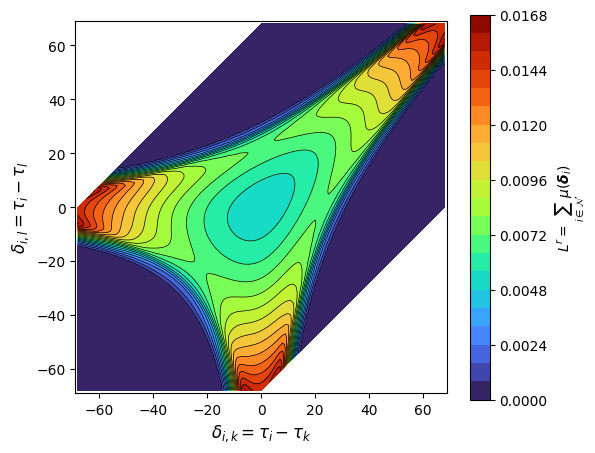

In [17]:
plt.figure(figsize=(6,5))
plt.contourf(X, Y, total_labor_demand, levels=20, cmap='turbo')
plt.colorbar(label=r'$L^r = \sum_{i\in\mathcal{N}} \mu(\boldsymbol{\delta}_{i})$')
plt.contour(X, Y, total_labor_demand, levels=20, colors='black', linewidths=0.5)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel(r'$\delta_{i,k} = \tau_i - \tau_k$', fontsize=12)
plt.ylabel(r'$\delta_{i,l} = \tau_i - \tau_l$', fontsize=12)
plt.savefig("../output/3-firm/python_plot/total_labor_demand_by_relative_state_diagonal_n3.png", bbox_inches='tight', dpi=400)

---
# Find stationary distribution

In [18]:
def eta(x, alpha = 5.0):
    res =  np.sqrt(alpha * x)
    return 0 if np.isnan(res) else res

In [19]:
state_space_2d = []
for idx_k in range(len(d_states)):
    for idx_l in range(len(d_states)):
        if np.isnan(p_grid[idx_k, idx_l]):
            continue
        state_space_2d.append((d_states[idx_k], d_states[idx_l]))
state_space_2d = np.array(state_space_2d)

In [20]:
idx_state_map = {
    (i, j): idx for idx, (i, j) in enumerate(state_space_2d)
}

In [21]:
P = np.zeros((len(state_space_2d), len(state_space_2d)))
P

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(14352, 14352))

In [22]:
for key, idx_current in idx_state_map.items():
    delta_ik, delta_il = key
    delta_ki = -delta_ik
    delta_li = -delta_il

    delta_kl = delta_il - delta_ik
    delta_lk = -delta_kl

    # print(f"Current state: ({delta_ik}, {delta_il})")
    # print(f"Transitions: delta_ki={delta_ki}, delta_li={delta_li}, delta_kl={delta_kl}, delta_lk={delta_lk}")

    if any(delta not in d_states for delta in [delta_ki, delta_li, delta_kl, delta_lk]):
        raise ValueError(f"State ({delta_ik}, {delta_il}) has invalid transitions.")
    
    if P[idx_current, :].sum() > 0:
        raise ValueError(f"State ({delta_ik}, {delta_il}) has already been processed.")

    idx_ki = np.where(d_states == delta_ki)[0][0]
    idx_li = np.where(d_states == delta_li)[0][0]
    idx_kl = np.where(d_states == delta_kl)[0][0]
    idx_lk = np.where(d_states == delta_lk)[0][0]
    idx_ik = np.where(d_states == delta_ik)[0][0]
    idx_il = np.where(d_states == delta_il)[0][0]

    labor_demand_i = p_grid[idx_ik, idx_il]
    labor_demand_k = p_grid[idx_ki, idx_kl]
    labor_demand_l = p_grid[idx_li, idx_lk]

    prob_i, prob_k, prob_l = eta(labor_demand_i), eta(labor_demand_k), eta(labor_demand_l)

    # print(f"Current state: ({delta_ik}, {delta_il})")
    # print(f"Probabilities: i={prob_i}, k={prob_k}, l={prob_l}")


    # Transition to (i innovates)
    new_delta_ik = delta_ik + 1
    new_delta_il = delta_il + 1
    if new_delta_ik in d_states and new_delta_il in d_states:
        idx_new = idx_state_map.get((new_delta_ik, new_delta_il))
        if idx_new is not None:
            prob = prob_i * (1 - prob_k) * (1 - prob_l)
            # print(P[idx_current, :].sum())
            # print(f"\tTransition to (i innovates):\t{prob} to state ({new_delta_ik}, {new_delta_il}), idx {idx_new}")
            P[idx_current, idx_new] += prob
            # print(P[idx_current, :].sum())

    # Transition to (k innovates)
    new_delta_ik = delta_ik - 1
    new_delta_il = delta_il
    if new_delta_ik in d_states and new_delta_il in d_states:
        idx_new = idx_state_map.get((new_delta_ik, new_delta_il))
        if idx_new is not None:
            prob = prob_k * (1 - prob_i) * (1 - prob_l)
            # print(f"\tTransition to (k innovates):\t{prob} to state ({new_delta_ik}, {new_delta_il}), idx {idx_new}")
            P[idx_current, idx_new] += prob
            # print(P[idx_current, :].sum())

    # Transition to (l innovates)
    new_delta_ik = delta_ik
    new_delta_il = delta_il - 1
    if new_delta_ik in d_states and new_delta_il in d_states:
        idx_new = idx_state_map.get((new_delta_ik, new_delta_il))
        if idx_new is not None:
            prob = prob_l * (1 - prob_i) * (1 - prob_k)
            # print(f"\tTransition to (l innovates):\t{prob} to state ({new_delta_ik}, {new_delta_il}), idx {idx_new}")
            P[idx_current, idx_new] += prob
            # print(P[idx_current, :].sum())

    # Transition to (i and k innovate)
    new_delta_ik = delta_ik
    new_delta_il = delta_il + 1
    if new_delta_ik in d_states and new_delta_il in d_states:
        idx_new = idx_state_map.get((new_delta_ik, new_delta_il))
        if idx_new is not None:
            prob = prob_i * prob_k * (1 - prob_l)
            # print(f"\tTransition to (i and k innovate):\t{prob} to state ({new_delta_ik}, {new_delta_il}), idx {idx_new}")
            P[idx_current, idx_new] += prob
            # print(P[idx_current, :].sum())

    # Transition to (i and l innovate)
    new_delta_ik = delta_ik + 1
    new_delta_il = delta_il
    if new_delta_ik in d_states and new_delta_il in d_states:
        idx_new = idx_state_map.get((new_delta_ik, new_delta_il))
        if idx_new is not None:
            prob = prob_i * prob_l * (1 - prob_k)
            # print(f"\tTransition to (i and l innovate):\t{prob} to state ({new_delta_ik}, {new_delta_il}), idx {idx_new}")
            P[idx_current, idx_new] += prob
            # print(P[idx_current, :].sum())

    # Transition to (k and l innovate)
    new_delta_ik = delta_ik - 1
    new_delta_il = delta_il - 1
    if new_delta_ik in d_states and new_delta_il in d_states:
        idx_new = idx_state_map.get((new_delta_ik, new_delta_il))
        if idx_new is not None:
            prob = prob_k * prob_l * (1 - prob_i)
            # print(f"\tTransition to (k and l innovate):\t{prob} to state ({new_delta_ik}, {new_delta_il}), idx {idx_new}")
            P[idx_current, idx_new] += prob

    # Transition to (all/non innovate) or illegal states
    prob =  P[idx_current, :].sum()
    # print(f"\tTotal transition probability so far:\t{prob}")
    if prob > 1:
        raise ValueError(f"Probabilities for state ({delta_ik}, {delta_il}) sum to more than 1.")
    P[idx_current, idx_current] += 1 - prob  # Ensure rows sum to 1

In [39]:
# Convert to sparse
P_sparse = csr_matrix(P)

# Compute the eigenvectors
eigenvalues, eigenvectors = eigs(P_sparse.T)

In [47]:
print(eigenvalues)

[1.        +0.j 1.        +0.j 1.        +0.j 0.99723442+0.j
 0.99723442+0.j 0.99723442+0.j]


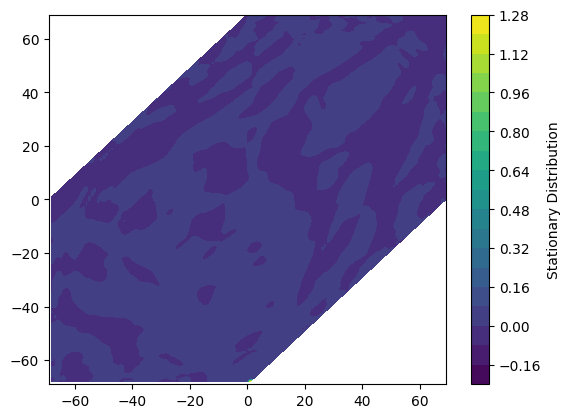

In [135]:
# Extract the stationary distribution
stationary_dist = np.real(eigenvectors[:, 0])

# Normalize 
stationary_dist = stationary_dist / stationary_dist.sum()

# Reshape to 2D grid for plotting
stationary_dist_grid = np.full(p_grid.shape, np.nan)
for (delta_ik, delta_il), idx in idx_state_map.items():
    idx_k = np.where(d_states == delta_ik)[0][0]
    idx_l = np.where(d_states == delta_il)[0][0]
    stationary_dist_grid[idx_k, idx_l] = stationary_dist[idx]

plt.contourf(X, Y, stationary_dist_grid, levels=20, cmap='viridis')
plt.colorbar(label='Stationary Distribution')

In [57]:
def convert_1d_to_2d(value_1d, idx_state_map, d_states):
    value_2d = np.full((len(d_states), len(d_states)), np.nan)
    for (delta_ik, delta_il), idx in idx_state_map.items():
        idx_k = np.where(d_states == delta_ik)[0][0]
        idx_l = np.where(d_states == delta_il)[0][0]
        value_2d[idx_k, idx_l] = value_1d[idx]
    return value_2d

100%|██████████| 700/700 [00:00<00:00, 3364.79it/s]


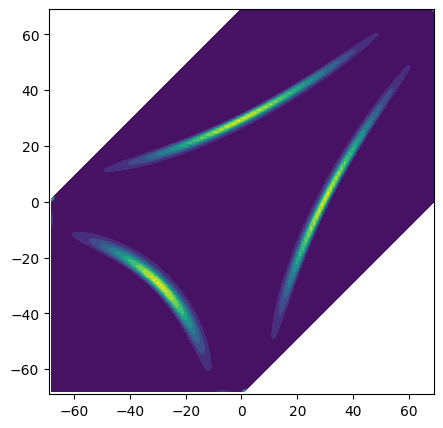

In [110]:
state = np.zeros((state_space_2d.shape[0], 1))
state[idx_state_map[(0, 0)], 0] = 1  # Start at the state where all firms are at the same technology level

for i in trange(700):
    state = P_sparse.T @ state
    if i % 100 == 0:
        state_2d = convert_1d_to_2d(state.flatten(), idx_state_map, d_states)
        
plt.figure(figsize=(5,5))
plt.gca().set_aspect('equal', adjustable='box')
plt.contourf(X, Y, state_2d, levels=10, cmap='viridis')
plt.show()

In [118]:
vmin, vmax = np.inf, -np.inf

state = np.zeros((state_space_2d.shape[0], 1))
state[idx_state_map[(0, 0)], 0] = 1

for i in range(700):
    state = P_sparse.T @ state
    
    if i % 100 == 0:
        vmin = min(vmin, state.min())
        vmax = max(vmax, state.max())

vmin, vmax

(np.float64(0.0), np.float64(0.7482192244124313))

In [127]:
# Create a folder for frames
os.makedirs("../output/3-firm/frames", exist_ok=True)

state = np.zeros((state_space_2d.shape[0], 1))
state[idx_state_map[(0, 0)], 0] = 1

frame_paths = []

for i in trange(751):
    state = P_sparse.T @ state

    if i % 10 == 0:
        state_2d = convert_1d_to_2d(state.flatten(), idx_state_map, d_states)

        fig, ax = plt.subplots(figsize=(5, 5))
        ax.set_aspect('equal', adjustable='box')

        contour = ax.contourf(X, Y, state_2d, levels=10, cmap='viridis')

        x_min, x_max = ax.get_xlim()

        # plot the boundary lines in the secondary column
        ax.plot(bnd_3 * -1, d_states * -1, 'g-.', linewidth=1)
        ax.plot(d_states * -1, bnd_2 * -1, 'b-.', linewidth=1)
        ax.plot(bnd_1[:, 0] + 1, bnd_1[:, 1] + 1, 'r-.', linewidth=1)

        ax.set_xlim(-x_max, x_max)
        ax.set_ylim(-x_max, x_max)

        ax.set_xlabel(r'$\delta_{i,k}$', fontsize=10)
        ax.set_ylabel(r'$\delta_{i,l}$', fontsize=10)
        ax.set_title(f"Iteration {i}", fontsize=12)

        # Optional: add colorbar
        # fig.colorbar(contour, ax=ax)

        # Save frame
        filename = f"../output/3-firm/frames/frame_{i:03d}.png"
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        frame_paths.append(filename)

        plt.close(fig)  # IMPORTANT to avoid memory issues

# Create GIF
with imageio.get_writer("../output/3-firm/evolution.gif", mode="I", duration=2) as writer:
    for path in frame_paths:
        image = imageio.imread(path)
        writer.append_data(image)

print("GIF saved as evolution.gif")

100%|██████████| 751/751 [00:05<00:00, 135.03it/s]
/var/folders/2_/37s1zdlx37z13rt227qsdtvr0000gp/T/ipykernel_80268/4095801153.py:47: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(path)


GIF saved as evolution.gif
